# Experiment 2A: SHD — Train-at-f / Eval-at-f Protocol

## Overview

This notebook implements Experiment 2A from the "Beyond Beyond Rate" project
under the **train-at-f / eval-at-f** protocol. For each perturbation level *f*
we instantiate a fresh 2-hidden-layer SNN, train it end-to-end on SHD with
hidden-layer perturbation active on every batch, then evaluate at the same *f*.

The hidden-layer perturbation is wired through a **straight-through estimator**
(`_apply_perturbation`) so that ``fc1`` still receives gradient signal — the
numpy round-trip in ``perturb_hidden_batch`` would otherwise sever the autograd
graph and freeze ``fc1`` at random init for any ``f > 0`` (see Section 7.1 of
``docs/progress/phase1to4_fixes.md``).

`delay1` was moved from the end of `_first_hidden` to the start of
`_second_hidden_and_output` (§3.4 Option B). This puts the perturbation hook
directly between `slayer.spike` and any further routing, matching the clean
layout of the synthetic `*_delay` notebooks.

**Architecture (post-refactor):**
```
Input → fc1 → spike → [hook] → (delay1) → fc2 → spike → (delay2) → fc3 → spike → output
```

**Dataset variants:** whole (700 input neurons), part (224), norm (224)

A global `USE_DELAY` flag selects whether to train with learnable delays
(SGD-delay) or without (SGD).

## 1. Imports and Setup

In [16]:
import os
import sys
import json
import random
from typing import Optional

import numpy as np
from scipy.io import loadmat
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

import slayerSNN as snn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 2. Global Configuration

All key hyper-parameters and switches are defined here so that switching
between dataset variants or delay/no-delay mode requires editing only
this cell.

In [17]:
# =====================================================================
# Batch mode: when True, the main run cell trains EVERY combination of
# (dataset_key, use_delay) listed in ALL_VARIATIONS case-by-case.
# When False, only the single (DATASET_KEY, USE_DELAY) pair below is run.
# =====================================================================
TRAIN_ALL_VARIATION: bool = True

# =====================================================================
# Network variant: set to True for SGD-delay, False for SGD (no delay).
# Ignored when TRAIN_ALL_VARIATION is True.
# =====================================================================
USE_DELAY: bool = True

# =====================================================================
# Dataset variant: "whole", "part", or "norm".
# Ignored when TRAIN_ALL_VARIATION is True.
# =====================================================================
DATASET_KEY: str = "norm"

# All (dataset_key, use_delay) pairs to iterate over in batch mode.
ALL_VARIATIONS: list[tuple[str, bool]] = [
    (dataset, delay)
    for dataset in ("norm", "part", "whole")
    for delay in (False, True)
]

# --- Dataset configurations ---
DATASET_CONFIGS = {
    "whole": {"mat_file": "shd_data/shd_whole.mat", "input_dim": 700},
    "part":  {"mat_file": "shd_data/shd_part_new.mat", "input_dim": 224},
    "norm":  {"mat_file": "shd_data/shd_norm_new.mat", "input_dim": 224},
}

# --- SLAYER neuron and simulation descriptors ---
SIM_PARAMS = {"Ts": 1, "tSample": 200}
LIF_PARAMS = {
    "type": "SRMALPHA",
    "theta": 10,
    "tauSr": 1,
    "tauRho": 0.1,
    "tauRef": 2,
    "scaleRef": 2,
    "scaleRho": 0.1,
}

# --- Data split ratios ---
TRAIN_RANGE = (0.0, 0.6)
VAL_RANGE = (0.6, 0.75)
TEST_RANGE = (0.75, 0.9)

# --- Training hyper-parameters ---
HIDDEN_UNITS: int = 128
NUM_CLASSES: int = 20
EPOCHS: int = 1250
BATCH_SIZE: int = 128
LEARNING_RATE: float = 0.1
SEED: int = 42
MAX_DELAY: int = 64
EARLY_STOP_PATIENCE: int = 300

# --- Hidden-perturbation sweep ---
F_VALUES: list[float] = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
NUM_REPEATS: int = 3

# --- Derived names (used only when TRAIN_ALL_VARIATION is False) ---
INPUT_DIM: int = DATASET_CONFIGS[DATASET_KEY]["input_dim"]
MAT_FILE: str = DATASET_CONFIGS[DATASET_KEY]["mat_file"]
DELAY_TAG: str = "delay" if USE_DELAY else "nodelay"
MODEL_PREFIX: str = f"shd_{DATASET_KEY}_{DELAY_TAG}"

if TRAIN_ALL_VARIATION:
    print(f"Batch mode: training {len(ALL_VARIATIONS)} variations:")
    for ds, ud in ALL_VARIATIONS:
        tag = "delay" if ud else "nodelay"
        print(f"  - shd_{ds}_{tag}")
else:
    print(f"Single variation: dataset={DATASET_KEY} | input_dim={INPUT_DIM}")
    print(f"  Network mode: {'SGD-delay' if USE_DELAY else 'SGD (no delay)'}")
    print(f"  Model prefix: {MODEL_PREFIX}")

Batch mode: training 6 variations:
  - shd_norm_nodelay
  - shd_norm_delay
  - shd_part_nodelay
  - shd_part_delay
  - shd_whole_nodelay
  - shd_whole_delay


## 3. Load SHD Dataset

Load the dense spike-train dataset from the local `.mat` file.
Each sample has shape `(num_neurons, T)` with binary spike values.
Time dimension is padded to 200 time steps to match `tSample`.

In [18]:
def load_shd_data(mat_path: str, target_T: int = 200) -> tuple[np.ndarray, np.ndarray]:
    """Load SHD dataset from a .mat file and pad time dimension.

    Args:
        mat_path: Path to the .mat file containing 'X' and 'Y'.
        target_T: Target time dimension (pad with zeros if shorter).

    Returns:
        Tuple of (X, Y) where X has shape (N, neurons, target_T).
    """
    data = loadmat(mat_path)
    X = data["X"]
    Y = data["Y"].ravel()

    n_samples, n_neurons, T = X.shape
    if T < target_T:
        padded = np.zeros((n_samples, n_neurons, target_T), dtype=X.dtype)
        padded[:, :, :T] = X
        X = padded
        print(f"Padded time dimension from {T} to {target_T}")

    print(f"Loaded {mat_path}: X={X.shape}, Y={Y.shape}, classes={len(np.unique(Y))}")
    return X, Y


X_all, Y_all = load_shd_data(MAT_FILE, target_T=SIM_PARAMS["tSample"])

Padded time dimension from 100 to 200
Loaded shd_data/shd_norm_new.mat: X=(5460, 224, 200), Y=(5460,), classes=20


## 4. Hidden-Layer Spike Perturbation

The core of the "Beyond Beyond Rate" approach. Given a hidden layer's binary
spike output of shape `(neurons, T)`, we randomly select a fraction `f` of
each neuron's spikes, remove them, and place the same number of spikes at
uniformly random (previously-silent) time bins. This destroys temporal
structure while preserving each neuron's spike count (i.e. the rate code).

In [19]:
def partial_randomize_spike_train(
    spike_train: np.ndarray,
    f: float = 0.0,
    max_attempts: int = 50,
) -> np.ndarray:
    """Randomly relocate a fraction *f* of each neuron's spikes (numpy ref impl).

    Kept for documentation / numpy-only callers. The training and evaluation
    paths use the vectorised GPU version ``perturb_hidden_batch`` below.

    Args:
        spike_train: Binary array of shape (num_neurons, T).
        f: Fraction of spikes to relocate (0 = no change, 1 = full shuffle).
        max_attempts: Max tries to find an empty time bin per spike.

    Returns:
        Perturbed spike train with same shape and spike counts.
    """
    if f <= 0:
        return spike_train

    num_neurons, T = spike_train.shape
    new_train = np.copy(spike_train)

    for neuron_idx in range(num_neurons):
        spike_times = np.where(spike_train[neuron_idx] == 1)[0]
        for old_time in spike_times:
            if np.random.rand() < f:
                new_train[neuron_idx, old_time] = 0
                inserted = False
                attempts = 0
                while not inserted and attempts < max_attempts:
                    attempts += 1
                    new_t = np.random.randint(0, T)
                    if new_train[neuron_idx, new_t] == 0:
                        new_train[neuron_idx, new_t] = 1
                        inserted = True
    return new_train


@torch.no_grad()
def perturb_hidden_batch(
    hidden_spikes: torch.Tensor,
    f: float = 0.0,
) -> torch.Tensor:
    """Vectorised GPU-side partial spike relocation.

    For each (batch, neuron), a fraction *f* of the existing spikes are
    removed and replaced with the same number of spikes placed at randomly
    chosen previously-unoccupied time bins. Spike count per neuron is
    preserved exactly. All operations stay on the input tensor's device,
    avoiding the CPU/numpy round-trip that dominates training cost when
    perturbation runs on every batch (mirrors the ``isi_delay`` version).

    Args:
        hidden_spikes: SLAYER-format tensor of shape (B, C, 1, 1, T).
        f: Fraction of spikes to relocate (0 = untouched, 1 = fully random).

    Returns:
        Perturbed tensor with the same shape, dtype, and device.
    """
    if f <= 0:
        return hidden_spikes

    B, C, H, W, T = hidden_spikes.shape
    x = hidden_spikes.view(B, C, T)
    is_spike = x > 0.5

    # Count spikes per (batch, neuron) and compute how many to move.
    n_spikes = is_spike.sum(dim=-1, keepdim=True)  # (B, C, 1)
    num_to_move = (n_spikes.float() * f).floor().long()  # (B, C, 1)

    # --- 1. Choose which existing spikes to remove ---
    # Random key per time bin; non-spike bins get +inf so they sort last.
    key = torch.rand_like(x)
    key = torch.where(is_spike, key, torch.full_like(key, 2.0))
    # rank[b, c, t] = position of t in the per-(b,c) ascending sort of `key`.
    rank = key.argsort(dim=-1).argsort(dim=-1)
    remove_mask = rank < num_to_move  # (B, C, T)

    keep_mask = is_spike & ~remove_mask

    # --- 2. Place the same number of spikes in currently-unoccupied bins ---
    available = ~keep_mask  # everything except positions we are keeping
    key2 = torch.rand_like(x)
    key2 = torch.where(available, key2, torch.full_like(key2, 2.0))
    rank2 = key2.argsort(dim=-1).argsort(dim=-1)
    add_mask = rank2 < num_to_move  # disjoint from keep_mask by construction

    new_spikes = (keep_mask | add_mask).to(hidden_spikes.dtype)
    return new_spikes.view(B, C, H, W, T)

## 5. Dataset and Data Splitting

A simple `Dataset` wrapper and a helper to split into train / validation / test
sets. Training always uses **unperturbed** data (f=0); perturbation is applied
only at test time inside the network's forward pass.

In [20]:
class SpikeDataset(Dataset):
    """Wrap numpy spike trains and labels into a PyTorch Dataset."""

    def __init__(self, X: np.ndarray, Y: np.ndarray):
        self.X = X
        self.Y = Y

    def __len__(self) -> int:
        return len(self.Y)

    def __getitem__(self, idx: int):
        x = torch.tensor(self.X[idx], dtype=torch.float32)
        y = torch.tensor(self.Y[idx], dtype=torch.long)
        return x, y


def get_split_indices(
    split_range: tuple[float, float],
    total: int,
) -> np.ndarray:
    """Return index array for a given fractional range of the dataset."""
    start = int(total * split_range[0])
    end = int(total * split_range[1])
    return np.arange(start, end)


def build_dataloaders(
    X: np.ndarray,
    Y: np.ndarray,
    batch_size: int = 128,
    seed: int = 42,
) -> tuple[DataLoader, DataLoader, DataLoader]:
    """Split data and build train/val/test DataLoaders.

    Args:
        X: Full dataset features, shape (N, neurons, T).
        Y: Full dataset labels, shape (N,).
        batch_size: Batch size for all loaders.
        seed: Random seed for train shuffle.

    Returns:
        Tuple of (train_loader, val_loader, test_loader).
    """
    N = len(Y)
    train_idx = get_split_indices(TRAIN_RANGE, N)
    val_idx = get_split_indices(VAL_RANGE, N)
    test_idx = get_split_indices(TEST_RANGE, N)

    np.random.seed(seed)
    np.random.shuffle(train_idx)

    train_ds = SpikeDataset(X[train_idx], Y[train_idx])
    val_ds = SpikeDataset(X[val_idx], Y[val_idx])
    test_ds = SpikeDataset(X[test_idx], Y[test_idx])

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

    print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")
    return train_loader, val_loader, test_loader

## 6. Network Architecture

A 2-hidden-layer SLAYER SNN matching the original SHD architecture, with
`delay1` repositioned per §3.4 Option B so that the perturbation hook sits
directly after `slayer.spike` on the 1st hidden layer.

```
Input → [PSP + fc1 + spike] → hidden1 spikes  ← [hook]
      → [delay1 + PSP + fc2 + spike] → (delay2) → hidden2 spikes
      → [PSP + fc3 + spike] → output
```

A single `forward(x, f)` routes the hidden spikes through
`_apply_perturbation` — a straight-through estimator that uses the
perturbed tensor as the forward value but lets gradients flow back through
the unperturbed `hidden1`. `f=0` preserves the previous unperturbed
behaviour exactly.

In [21]:
class SHDNetwork(nn.Module):
    """2-hidden-layer SLAYER SNN for SHD classification.

    ``delay1`` is applied at the start of ``_second_hidden_and_output``
    (§3.4 Option B) so the perturbation hook sees the 1st hidden layer's
    binary spike output directly. ``forward(x, f)`` applies the
    spike-relocation perturbation through a straight-through estimator,
    keeping the gradient path to ``fc1`` intact during training.
    """

    def __init__(
        self,
        input_dim: int,
        hidden_units: int = 128,
        num_classes: int = 20,
        use_delay: bool = True,
        max_delay: int = 64,
    ):
        super().__init__()
        slayer = snn.layer(LIF_PARAMS, SIM_PARAMS)
        self.slayer = slayer
        self.use_delay = use_delay
        self.max_delay = max_delay

        # Three FC layers with weight normalisation
        self.fc1 = nn.utils.weight_norm(
            slayer.dense(input_dim, hidden_units), name="weight"
        )
        self.fc2 = nn.utils.weight_norm(
            slayer.dense(hidden_units, hidden_units), name="weight"
        )
        self.fc3 = nn.utils.weight_norm(
            slayer.dense(hidden_units, num_classes), name="weight"
        )

        # Optional learnable delay modules.
        # delay1 lives at the start of _second_hidden_and_output (after the
        # perturbation hook); delay2 stays between fc2-spike and fc3.
        if use_delay:
            self.delay1 = slayer.delay(hidden_units)
            self.delay2 = slayer.delay(hidden_units)

    # -----------------------------------------------------------------
    # Forward-pass building blocks
    # -----------------------------------------------------------------
    def _prepare_input(self, x: torch.Tensor) -> torch.Tensor:
        """Ensure input is 5-D NCHWT on the correct device."""
        if isinstance(x, np.ndarray):
            x = torch.from_numpy(x)
        if x.dim() == 3:
            x = x.unsqueeze(2).unsqueeze(3)
        return x.float().to(device)

    def _first_hidden(self, x: torch.Tensor) -> torch.Tensor:
        """Input -> PSP -> fc1 -> spike -> hidden1 spikes (strictly binary)."""
        return self.slayer.spike(self.fc1(self.slayer.psp(x)))

    def _second_hidden_and_output(self, hidden1: torch.Tensor) -> torch.Tensor:
        """hidden1 -> (delay1) -> PSP -> fc2 -> spike -> (delay2) -> PSP -> fc3 -> spike."""
        x = hidden1
        if self.use_delay:
            x = self.delay1(x)
        x = self.slayer.spike(self.fc2(self.slayer.psp(x)))
        if self.use_delay:
            x = self.delay2(x)
        x = self.slayer.spike(self.fc3(self.slayer.psp(x)))
        return x

    def _apply_perturbation(
        self,
        hidden: torch.Tensor,
        f: float,
    ) -> torch.Tensor:
        """STE wrapper around ``perturb_hidden_batch``.

        Without this wrapper the numpy round-trip in
        ``perturb_hidden_batch`` would return a fresh leaf, blocking
        gradient flow to ``fc1`` and freezing it at random init for any
        ``f > 0`` (Section 7.1 of ``docs/progress/phase1to4_fixes.md``).
        """
        if f <= 0:
            return hidden
        perturbed = perturb_hidden_batch(hidden, f)
        return hidden + (perturbed - hidden).detach()

    def forward(self, x: torch.Tensor, f: float = 0.0) -> torch.Tensor:
        """Forward pass with optional hidden-layer perturbation at level *f*."""
        x = self._prepare_input(x)
        hidden1 = self._first_hidden(x)
        hidden1 = self._apply_perturbation(hidden1, f)
        return self._second_hidden_and_output(hidden1)

    def clamp_delays(self, max1: int = 64, max2: int = 64) -> None:
        """Clamp delay parameters to [0, max]."""
        if not self.use_delay:
            return
        self.delay1.delay.data.clamp_(0, max1)
        self.delay2.delay.data.clamp_(0, max2)

    def get_delays(self) -> dict[str, np.ndarray]:
        """Return current delay values as a dict."""
        delays = {}
        if self.use_delay:
            delays["delay1"] = self.delay1.delay.data.cpu().numpy()
            delays["delay2"] = self.delay2.delay.data.cpu().numpy()
        return delays

## 7. Training Loop

Train one model end-to-end with perturbation level *f* active on every
training and validation batch — the best checkpoint (lowest validation
loss) sees the same perturbation it will be evaluated under. SLAYER
`NumSpikes` loss, Nadam optimiser, multi-step LR schedule, adaptive
delay clamping (matching the original SHD training script).

In [22]:
def set_seed(seed: int) -> None:
    """Set random seeds for reproducibility."""
    import torch.backends.cudnn as cudnn
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        cudnn.benchmark = False
        cudnn.deterministic = True
        cudnn.enabled = False


def build_loss_and_optimizer(
    net: SHDNetwork,
    lr: float = 0.1,
) -> tuple:
    """Build SpikeRate loss, Nadam optimizer, and LR scheduler."""
    error_cfg = {
        "neuron": LIF_PARAMS,
        "simulation": SIM_PARAMS,
        "training": {
            "error": {
                "type": "NumSpikes",
                "tgtSpikeRegion": {"start": 0, "stop": 200},
                "tgtSpikeCount": {True: 40, False: 4},
            }
        },
    }
    loss_fn = snn.spikeLoss.spikeLoss(error_cfg)
    optimizer = snn.utils.optim.Nadam(net.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.MultiStepLR(
        optimizer, milestones=[300], gamma=0.1
    )
    return loss_fn, optimizer, scheduler


def train_model(
    train_loader: DataLoader,
    val_loader: DataLoader,
    input_dim: int,
    hidden_units: int = 128,
    num_classes: int = 20,
    use_delay: bool = True,
    max_delay: int = 64,
    epochs: int = 1000,
    lr: float = 0.1,
    seed: int = 42,
    patience: int = 300,
    f: float = 0.0,
) -> tuple[SHDNetwork, dict]:
    """Train the SHDNetwork with perturbation level *f* active on every batch.

    Args:
        train_loader: Training DataLoader.
        val_loader: Validation DataLoader.
        input_dim: Number of input neurons.
        hidden_units: Hidden layer size.
        num_classes: Number of output classes.
        use_delay: Whether to use learnable delays.
        max_delay: Maximum delay in time steps.
        epochs: Maximum training epochs.
        lr: Learning rate.
        seed: Random seed; re-seeded inside so each f starts from the same init.
        patience: Early stopping patience.
        f: Hidden-layer perturbation level applied during forward passes.

    Returns:
        Tuple of (trained network, training log dict).
    """
    set_seed(seed)

    net = SHDNetwork(
        input_dim, hidden_units, num_classes, use_delay, max_delay
    ).to(device)
    loss_fn, optimizer, scheduler = build_loss_and_optimizer(net, lr=lr)
    loss_fn = loss_fn.to(device)

    best_val_loss = float("inf")
    best_model_state = None
    early_stop_counter = 0

    # Adaptive delay clamping state
    update1 = 0
    update2 = 0
    thea1 = max_delay
    thea2 = max_delay

    log: dict = {
        "epoch": [],
        "train_loss": [],
        "val_loss": [],
        "val_acc": [],
        "delay_mean": [],
        "f": f,
    }

    total_steps = epochs * len(train_loader)
    with tqdm(total=total_steps, desc=f"Train f={f}") as pbar:
        for epoch in range(epochs):
            # --- Train ---
            net.train()
            batch_losses = []

            for x_batch, y_batch in train_loader:
                x_batch = x_batch.unsqueeze(2).unsqueeze(3).float().to(device)
                y_batch = y_batch.to(device).long()

                target = torch.zeros(
                    (len(y_batch), num_classes, 1, 1, 1), device=device
                )
                target.scatter_(1, y_batch[:, None, None, None, None], 1.0)

                outputs = net(x_batch, f=f)
                loss = loss_fn.numSpikes(outputs, target)

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

                batch_losses.append(loss.item())
                pbar.update(1)

            # --- Adaptive delay clamping ---
            if use_delay:
                if epoch <= 250:
                    net.clamp_delays(max_delay, max_delay)
                else:
                    update1 += 1
                    update2 += 1
                    for name, param in net.named_parameters():
                        if "delay1.delay" in name and update1 > 150:
                            sorted_ = torch.sort(
                                torch.floor(param.detach().flatten())
                            )[0]
                            thea1_val = torch.max(sorted_)
                            if sorted_[108] > (thea1_val - 5):
                                thea1 = int(thea1_val.item()) + 1
                                update1 = 0
                        elif "delay2.delay" in name and update2 > 150:
                            sorted_ = torch.sort(
                                torch.floor(param.detach().flatten())
                            )[0]
                            thea2_val = torch.max(sorted_)
                            if sorted_[108] > (thea2_val - 5):
                                thea2 = int(thea2_val.item()) + 1
                                update2 = 0
                    net.clamp_delays(thea1, thea2)

            # --- Validate (with same perturbation) ---
            net.eval()
            val_loss = 0.0
            correct = 0
            total = 0
            with torch.no_grad():
                for x_batch, y_batch in val_loader:
                    x_batch = (
                        x_batch.unsqueeze(2).unsqueeze(3).float().to(device)
                    )
                    y_batch = y_batch.to(device).long()

                    target = torch.zeros(
                        (len(y_batch), num_classes, 1, 1, 1), device=device
                    )
                    target.scatter_(
                        1, y_batch[:, None, None, None, None], 1.0
                    )

                    outputs = net(x_batch, f=f)
                    val_loss += loss_fn.numSpikes(outputs, target).item()

                    pred = snn.predict.getClass(outputs)
                    correct += (pred.cpu() == y_batch.cpu()).sum().item()
                    total += len(y_batch)

            val_loss /= max(1, len(val_loader))
            val_acc = correct / max(1, total)
            train_loss = np.mean(batch_losses)

            # Log delay statistics
            delays = net.get_delays()
            avg_delay = (
                np.mean([
                    np.mean(d) for d in delays.values() if len(d) > 0
                ])
                if delays
                else 0.0
            )

            log["epoch"].append(epoch)
            log["train_loss"].append(float(train_loss))
            log["val_loss"].append(float(val_loss))
            log["val_acc"].append(float(val_acc))
            log["delay_mean"].append(float(avg_delay))

            pbar.set_postfix(
                epoch=epoch + 1,
                train=f"{train_loss:.3f}",
                val=f"{val_loss:.3f}",
                acc=f"{val_acc:.2%}",
                delay=f"{avg_delay:.1f}",
            )
            scheduler.step()

            # Early stopping
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_model_state = {
                    k: v.clone() for k, v in net.state_dict().items()
                }
                early_stop_counter = 0
            else:
                early_stop_counter += 1
                if early_stop_counter >= patience:
                    print(f"\nEarly stopping at epoch {epoch + 1}")
                    break

    if best_model_state is not None:
        net.load_state_dict(best_model_state)

    return net, log

## 8. Testing with Hidden-Layer Perturbation

``test_with_hidden_perturbation`` evaluates a trained model at a given *f*;
``test_with_repeats`` wraps it with ``NUM_REPEATS`` independent draws of the
random spike-placement RNG so we get error bars. Under the train-at-f /
eval-at-f protocol these are called once per *f* by the main sweep loop in
§10 (each call uses the model trained at that *f*).

In [23]:
def test_with_hidden_perturbation(
    net: SHDNetwork,
    test_loader: DataLoader,
    f: float = 0.0,
) -> float:
    """Evaluate accuracy with hidden-layer perturbation at level *f*."""
    net.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            x_batch = x_batch.unsqueeze(2).unsqueeze(3).float().to(device)
            y_batch = y_batch.to(device)

            outputs = net(x_batch, f=f)
            predicted = snn.predict.getClass(outputs)

            total += y_batch.size(0)
            correct += (predicted.cpu() == y_batch.cpu()).sum().item()

    return correct / total


def test_with_repeats(
    net: SHDNetwork,
    test_loader: DataLoader,
    f: float,
    num_repeats: int = 3,
) -> dict:
    """Repeat ``test_with_hidden_perturbation`` for mean ± std error bars."""
    accuracies: list[float] = []
    for repeat in range(num_repeats):
        np.random.seed(SEED + repeat)
        torch.manual_seed(SEED + repeat)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(SEED + repeat)
        accuracies.append(test_with_hidden_perturbation(net, test_loader, f=f))
    return {
        "mean": float(np.mean(accuracies)),
        "std": float(np.std(accuracies)),
        "values": [float(a) for a in accuracies],
    }

## 9. Visualisation Utilities

Plotting helpers for:
1. Training curves (loss, validation accuracy, and delay evolution).
2. Accuracy vs. hidden-perturbation level *f* (the main result).

In [24]:
def plot_training_curves(log: dict) -> None:
    """Plot training / validation loss, accuracy, and delay evolution."""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    f_val = log.get("f", 0.0)

    # Loss curves
    axes[0].plot(
        log["epoch"], log["train_loss"],
        "o-", label="Train loss", markersize=2,
    )
    axes[0].plot(
        log["epoch"], log["val_loss"],
        "s-", label="Val loss", markersize=2,
    )
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_title(f"Training and Validation Loss (f={f_val})")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Validation accuracy
    axes[1].plot(
        log["epoch"], log["val_acc"],
        "o-", color="green", markersize=2,
    )
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_title(f"Validation Accuracy (f={f_val})")
    axes[1].grid(True, alpha=0.3)

    # Delay evolution
    if any(d != 0.0 for d in log["delay_mean"]):
        axes[2].plot(log["epoch"], log["delay_mean"], color="purple")
        axes[2].set_xlabel("Epoch")
        axes[2].set_ylabel("Mean Delay (time steps)")
        axes[2].set_title(f"Average Delay Over Training (f={f_val})")
        axes[2].grid(True, alpha=0.3)
    else:
        axes[2].text(
            0.5, 0.5, "No delays\n(SGD mode)",
            ha="center", va="center", fontsize=14,
            transform=axes[2].transAxes,
        )
        axes[2].set_title("Delay Evolution (N/A)")

    plt.suptitle(
        f"SHD {DATASET_KEY} ({DELAY_TAG}) Training Curves — f={f_val}",
        fontsize=14,
    )
    plt.tight_layout()
    plt.show()


def plot_hidden_perturbation_curve(
    results: dict[float, dict],
) -> None:
    """Plot accuracy vs hidden perturbation level f (train-at-f / eval-at-f)."""
    f_vals = sorted(results.keys())
    means = [results[f]["mean"] for f in f_vals]
    stds = [results[f]["std"] for f in f_vals]

    color = "tab:orange" if USE_DELAY else "tab:blue"
    label = (
        f"SGD-delay ({DATASET_KEY})"
        if USE_DELAY
        else f"SGD ({DATASET_KEY})"
    )

    plt.figure(figsize=(8, 5))
    plt.errorbar(
        f_vals, means, yerr=stds, fmt="o-",
        capsize=5, capthick=2, color=color, label=label,
    )
    plt.xlabel("Hidden Perturbation Level (f) — trained & evaluated at this f")
    plt.ylabel("Test Accuracy")
    plt.title(
        f"Exp 2A: SHD {DATASET_KEY} — Train-at-f / Eval-at-f ({DELAY_TAG})"
    )
    plt.ylim(0, 1.05)
    plt.grid(True, alpha=0.3)
    plt.legend()

    for f_val, mean, std in zip(f_vals, means, stds):
        plt.annotate(
            f"{mean:.3f}",
            (f_val, mean),
            textcoords="offset points",
            xytext=(0, 12),
            ha="center",
            fontsize=9,
        )

    plt.tight_layout()
    fig_path = (
        f"log/shd_{DATASET_KEY}_{DELAY_TAG}_hidden_perturbation.png"
    )
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Figure saved to {fig_path}")

## 10. Run: Train-at-f / Eval-at-f Sweep

`run_variation_sweep` wraps the full per-variation pipeline — load data,
build dataloaders, train one fresh model per *f*, save the checkpoint and
the JSON sweep result. When `TRAIN_ALL_VARIATION` is `True`, it is called
once for every (dataset_key, use_delay) pair in `ALL_VARIATIONS` (6
variations total) so you can launch the whole grid in a single cell.
Otherwise it runs once on the configured `(DATASET_KEY, USE_DELAY)` pair.

Each variation persists its own files under `data/` and `log/`:
- `data/shd_{dataset}_{tag}_f{f}.pt`
- `log/shd_{dataset}_{tag}_hidden_perturbation_results.json`
- `log/shd_{dataset}_{tag}_training_log.json`

In-memory state (`all_models`, `all_logs`, `sweep_results`, `test_loader`)
mirrors the *last* variation run, so the downstream diagnostic / plotting
/ analysis cells operate on it. To inspect a particular variation, rerun
this notebook with `TRAIN_ALL_VARIATION = False` and the target
`(DATASET_KEY, USE_DELAY)`. SHD-whole at 500–800 epochs × 6 levels is
expensive (~5–6 h per variation) — batch mode multiplies that by 6.

In [25]:
def run_variation_sweep(
    dataset_key: str,
    use_delay: bool,
) -> dict:
    """Train-at-f / eval-at-f sweep for one (dataset_key, use_delay) variation.

    Loads the dataset, builds dataloaders, trains one fresh model per
    f in F_VALUES with the perturbation active during training, evaluates
    each at the same f, and persists per-variation checkpoints + JSON.

    Args:
        dataset_key: One of "norm", "part", "whole".
        use_delay: Train the SGD-delay variant if True, else SGD.

    Returns:
        Dict with keys models / logs / results / test_loader / model_prefix
        / dataset_key / use_delay for the variation.
    """
    cfg = DATASET_CONFIGS[dataset_key]
    input_dim = cfg["input_dim"]
    mat_file = cfg["mat_file"]
    delay_tag = "delay" if use_delay else "nodelay"
    model_prefix = f"shd_{dataset_key}_{delay_tag}"

    print(f"\n{'#' * 70}")
    print(f"# Variation: dataset={dataset_key} | delay={delay_tag}")
    print(f"# Model prefix: {model_prefix}")
    print(f"{'#' * 70}")

    X, Y = load_shd_data(mat_file, target_T=SIM_PARAMS["tSample"])
    train_loader, val_loader, test_loader = build_dataloaders(
        X, Y, batch_size=BATCH_SIZE, seed=SEED,
    )

    models: dict[float, SHDNetwork] = {}
    logs: dict[float, dict] = {}
    results: dict[float, dict] = {}

    for f_val in F_VALUES:
        print(f"\n=== Training {model_prefix} at f={f_val} ===")
        net, training_log = train_model(
            train_loader=train_loader,
            val_loader=val_loader,
            input_dim=input_dim,
            hidden_units=HIDDEN_UNITS,
            num_classes=NUM_CLASSES,
            use_delay=use_delay,
            max_delay=MAX_DELAY,
            epochs=EPOCHS,
            lr=LEARNING_RATE,
            seed=SEED,
            patience=EARLY_STOP_PATIENCE,
            f=f_val,
        )

        model_path = f"data/{model_prefix}_f{f_val}.pt"
        torch.save(net.state_dict(), model_path)

        result = test_with_repeats(net, test_loader, f=f_val, num_repeats=NUM_REPEATS)
        models[f_val] = net
        logs[f_val] = training_log
        results[f_val] = result
        print(
            f"f={f_val} | test acc = {result['mean']:.4f} ± {result['std']:.4f}"
            f" | checkpoint -> {model_path}"
        )

    # Per-variation JSON persistence.
    results_serialisable = {
        str(f_val): {
            "mean": float(d["mean"]),
            "std": float(d["std"]),
            "values": [float(v) for v in d["values"]],
        }
        for f_val, d in results.items()
    }
    results_path = f"log/{model_prefix}_hidden_perturbation_results.json"
    with open(results_path, "w") as fp:
        json.dump(results_serialisable, fp, indent=2)
    print(f"Results saved to {results_path}")

    training_logs_serialisable = {
        str(f_val): {
            k: ([float(v) for v in vals] if isinstance(vals, list) else vals)
            for k, vals in log.items()
        }
        for f_val, log in logs.items()
    }
    log_path = f"log/{model_prefix}_training_log.json"
    with open(log_path, "w") as fp:
        json.dump(training_logs_serialisable, fp, indent=2)
    print(f"Training logs saved to {log_path}")

    return {
        "models": models,
        "logs": logs,
        "results": results,
        "test_loader": test_loader,
        "model_prefix": model_prefix,
        "dataset_key": dataset_key,
        "use_delay": use_delay,
    }


os.makedirs("data", exist_ok=True)
os.makedirs("log", exist_ok=True)

variations_to_run = (
    ALL_VARIATIONS if TRAIN_ALL_VARIATION else [(DATASET_KEY, USE_DELAY)]
)

all_variation_runs: dict[tuple[str, bool], dict] = {}
for _ds_key, _use_delay in variations_to_run:
    _run = run_variation_sweep(_ds_key, _use_delay)
    all_variation_runs[(_ds_key, _use_delay)] = _run

# Expose the most recent variation's state under the names the downstream
# diagnostic / plotting / analysis cells use.
all_models = _run["models"]
all_logs = _run["logs"]
sweep_results = _run["results"]
test_loader = _run["test_loader"]


######################################################################
# Variation: dataset=norm | delay=nodelay
# Model prefix: shd_norm_nodelay
######################################################################
Padded time dimension from 100 to 200
Loaded shd_data/shd_norm_new.mat: X=(5460, 224, 200), Y=(5460,), classes=20
Train: 3276 | Val: 819 | Test: 819

=== Training shd_norm_nodelay at f=0.0 ===


d:\IC_2025\IRP\workspace\venv\Lib\site-packages\torch\nn\utils\weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)
Train f=0.0:  55%|█████▍    | 17758/32500 [43:48<36:21,  6.76it/s, acc=20.02%, delay=0.0, epoch=683, train=346.941, val=344.358]    



Early stopping at epoch 683
f=0.0 | test acc = 0.2418 ± 0.0000 | checkpoint -> data/shd_norm_nodelay_f0.0.pt

=== Training shd_norm_nodelay at f=0.2 ===


Train f=0.2:  61%|██████    | 19864/32500 [39:33<25:10,  8.37it/s, acc=17.83%, delay=0.0, epoch=764, train=364.451, val=350.467]  



Early stopping at epoch 764
f=0.2 | test acc = 0.2007 ± 0.0050 | checkpoint -> data/shd_norm_nodelay_f0.2.pt

=== Training shd_norm_nodelay at f=0.4 ===


...

f=0.6 | test acc = 0.7157 ± 0.0090 | checkpoint -> data/shd_whole_delay_f0.6.pt

=== Training shd_whole_delay at f=0.8 ===


Train f=0.8: 100%|██████████| 58750/58750 [2:32:52<00:00,  6.41it/s, acc=65.89%, delay=36.3, epoch=1250, train=243.486, val=253.104]  


f=0.8 | test acc = 0.6094 ± 0.0025 | checkpoint -> data/shd_whole_delay_f0.8.pt

=== Training shd_whole_delay at f=1.0 ===


Train f=1.0: 100%|██████████| 58750/58750 [2:30:48<00:00,  6.49it/s, acc=59.15%, delay=29.5, epoch=1250, train=266.951, val=269.938]  


f=1.0 | test acc = 0.5462 ± 0.0072 | checkpoint -> data/shd_whole_delay_f1.0.pt
Results saved to log/shd_whole_delay_hidden_perturbation_results.json
Training logs saved to log/shd_whole_delay_training_log.json


## 10b. Diagnostic — STE Health Check

Per §3.6 / §5 of `docs/progress/phase1to4_fixes.md`. Two `f>0` rows with
identical `fc1.norm` mean the STE regressed (Issue 1). `hidden_unique`
should be `[0.0, 1.0]` — non-binary values mean the delay refactor
regressed (Issue 2).

In [26]:
print(f"{'f':>6}  {'fc1.norm':>10}  hidden_unique")
for f_val, mdl in all_models.items():
    fc1_norm = sum(
        p.norm().item()
        for name, p in mdl.named_parameters()
        if name.startswith("fc1.weight")
    )
    with torch.no_grad():
        x_b, _ = next(iter(test_loader))
        x_b = x_b.unsqueeze(2).unsqueeze(3).float().to(device)
        hidden = mdl._first_hidden(x_b)
        unique = torch.unique(hidden).cpu().tolist()
    print(f"{f_val:>6.2f}  {fc1_norm:>10.4f}  {unique}")

     f    fc1.norm  hidden_unique
  0.00   3929.6815  [0.0, 1.0]
  0.20   3944.4022  [0.0, 1.0]
  0.40   4164.2145  [0.0, 1.0]
  0.60   4133.8810  [0.0, 1.0]
  0.80   4034.6374  [0.0, 1.0]
  1.00   3813.1065  [0.0, 1.0]


## 11. Plot Training Curves (per f)

Plot loss, validation accuracy and delay evolution for each trained model.


--- Training curves at f=0.0 ---


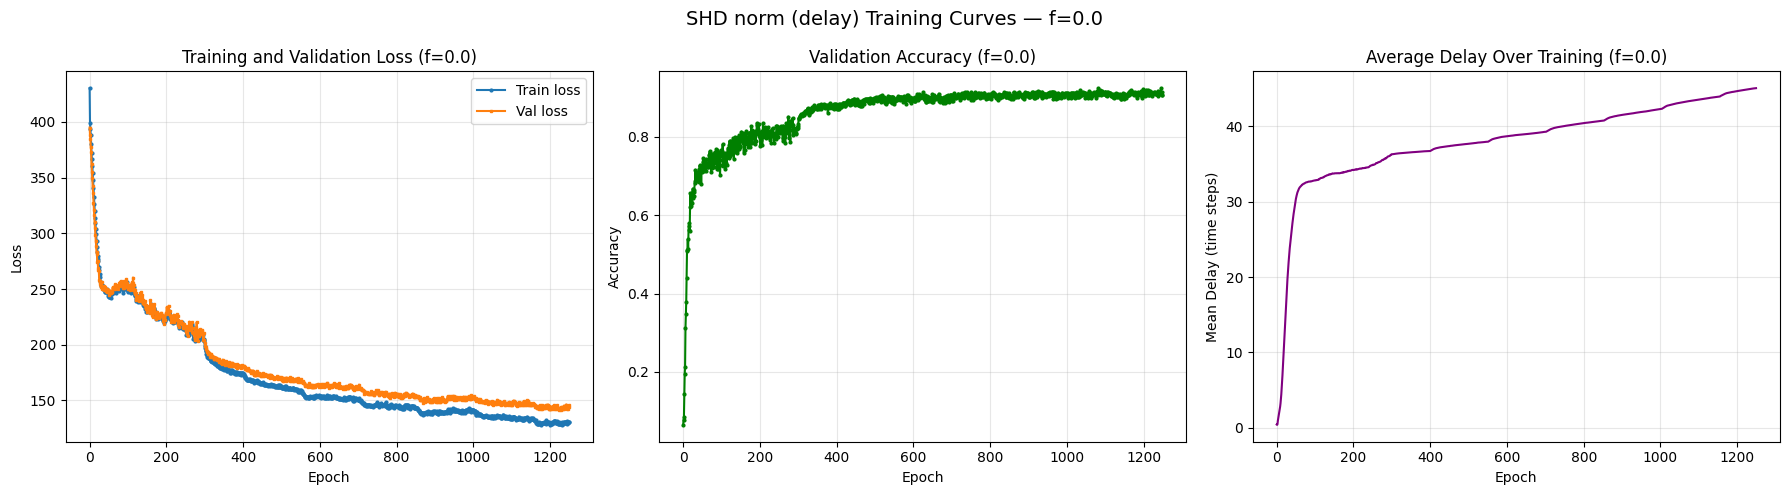


--- Training curves at f=0.2 ---


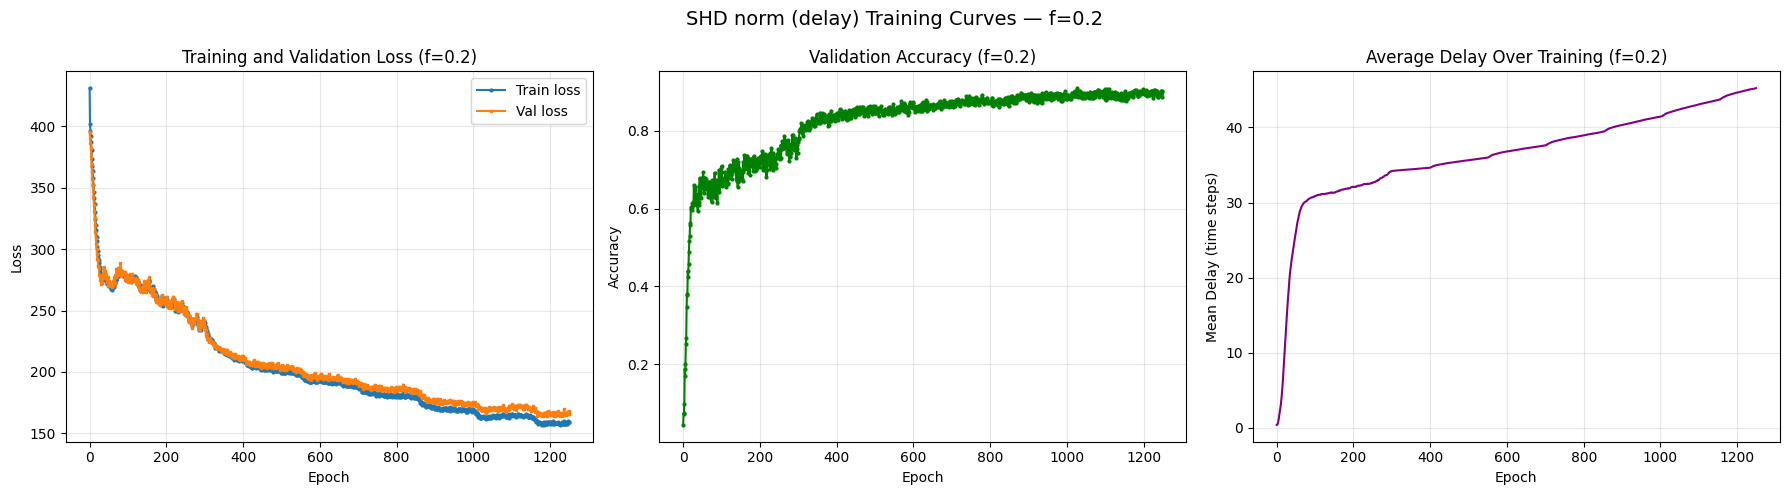


--- Training curves at f=0.4 ---


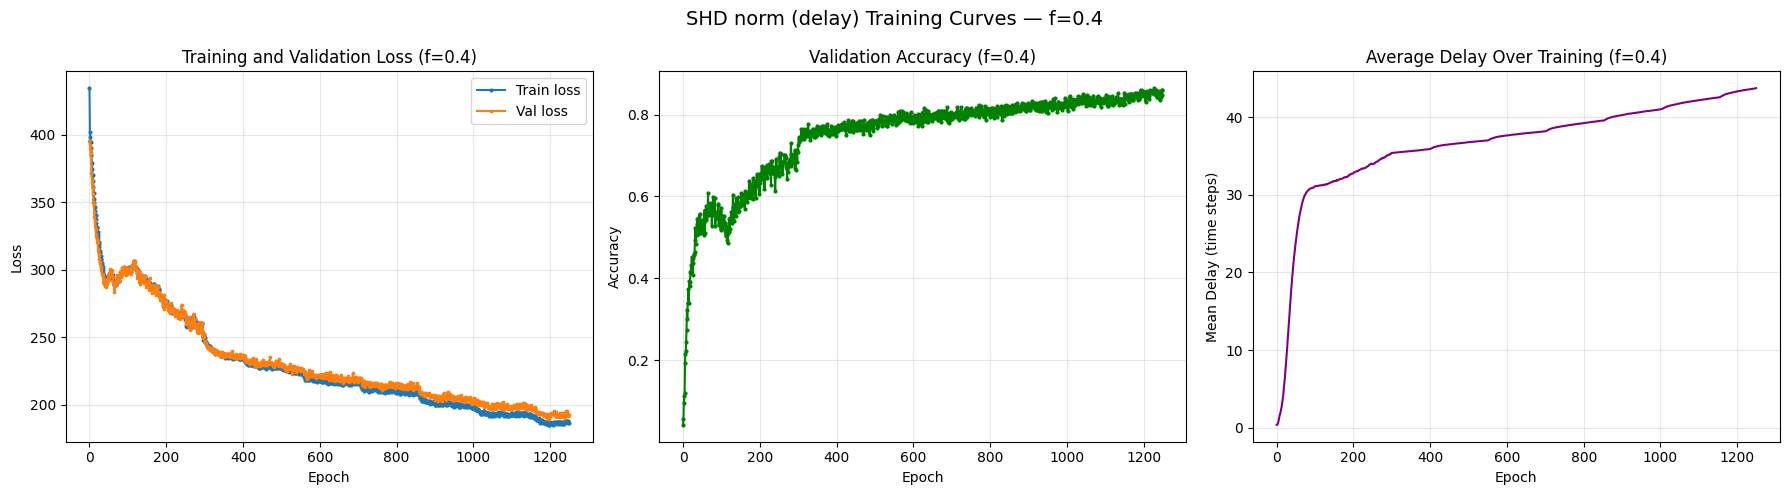


--- Training curves at f=0.6 ---


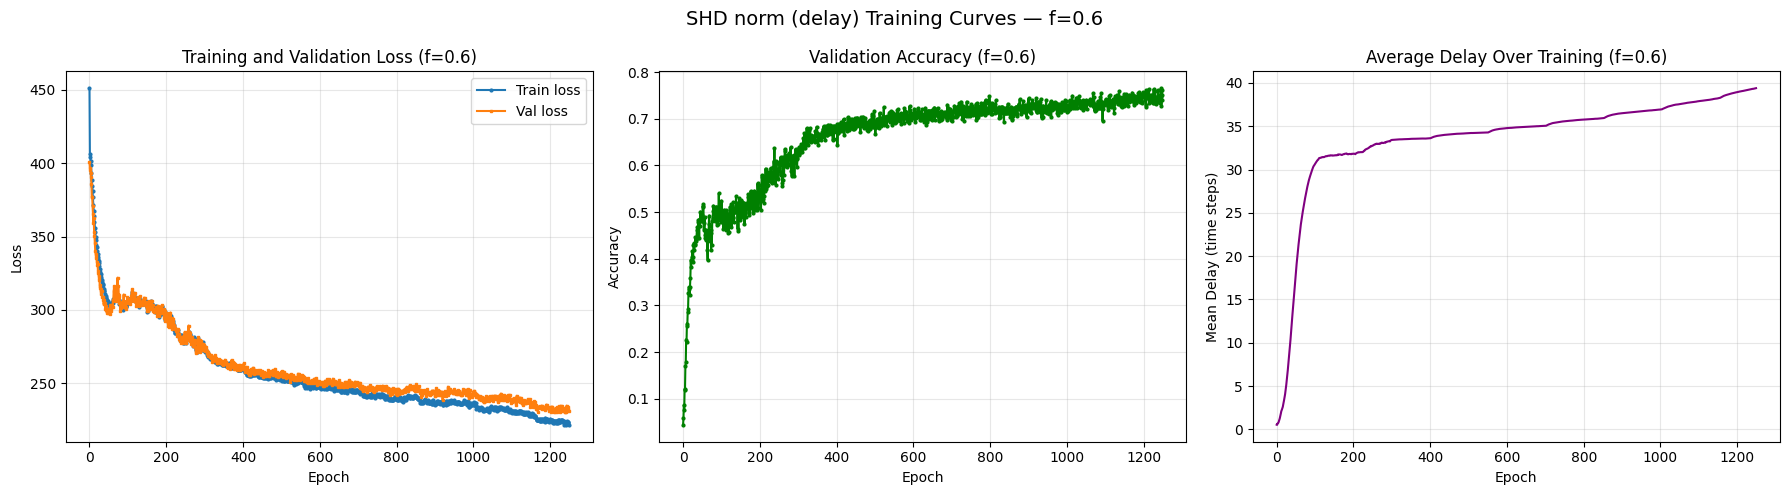


--- Training curves at f=0.8 ---


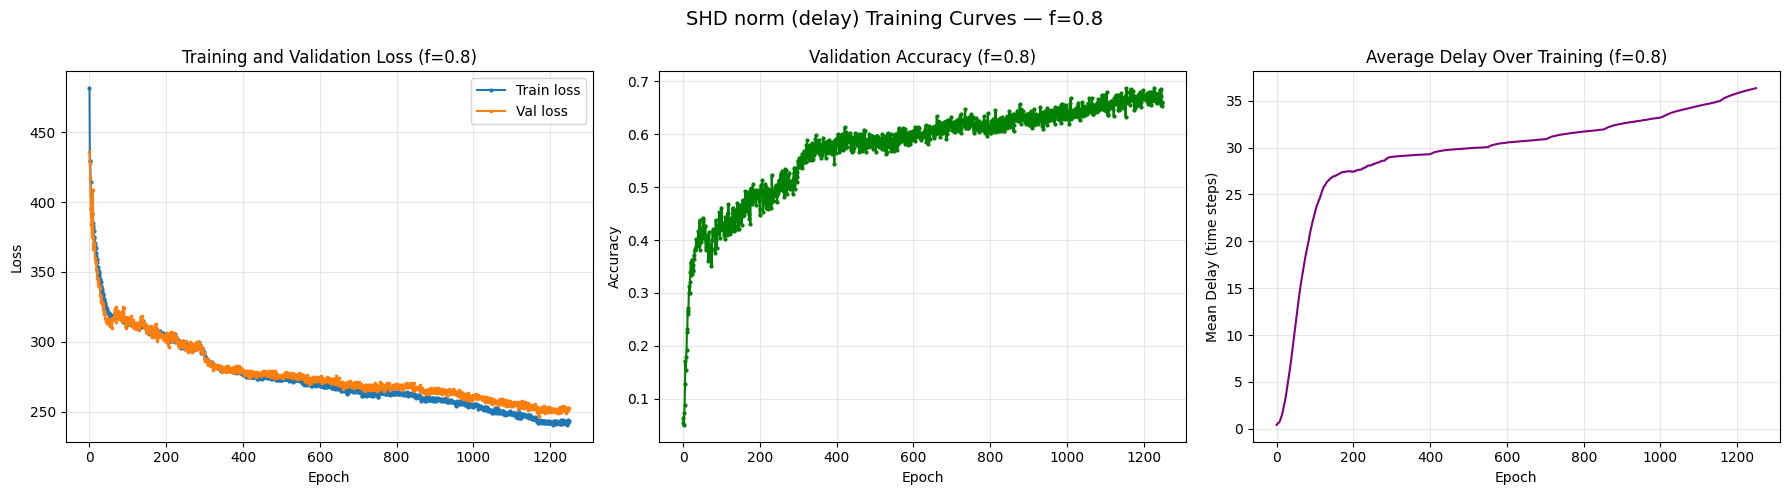


--- Training curves at f=1.0 ---


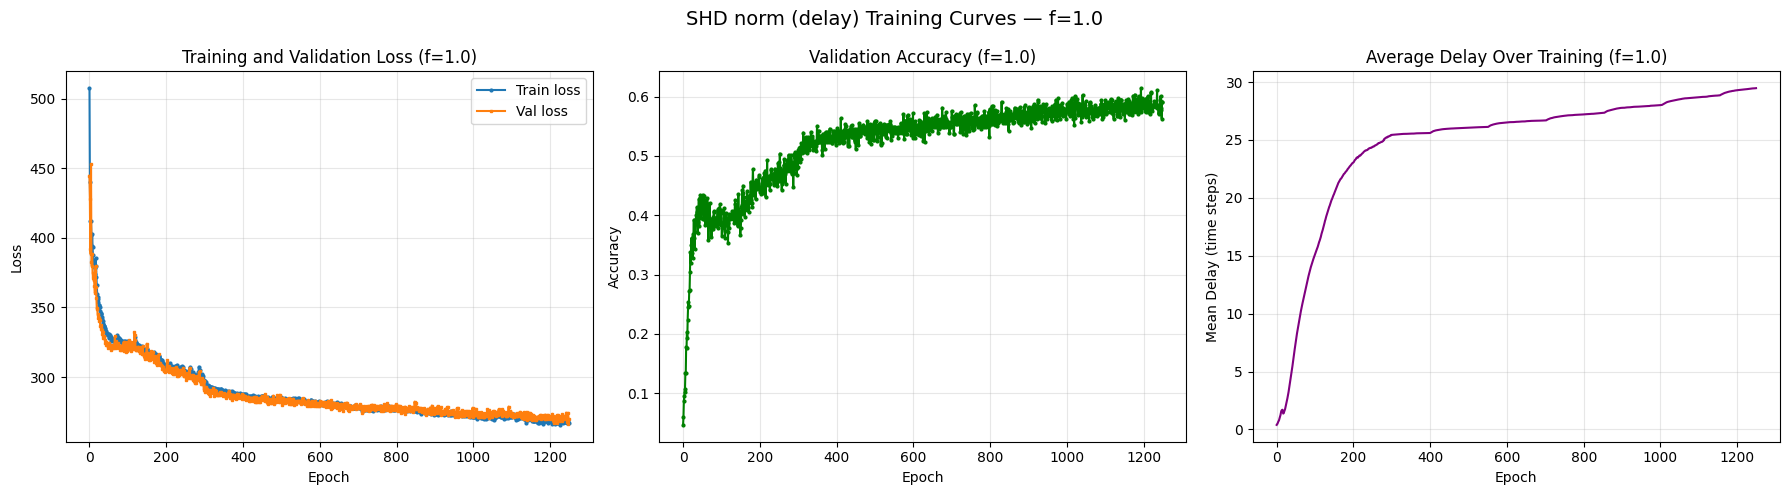

In [27]:
for f_val in F_VALUES:
    print(f"\n--- Training curves at f={f_val} ---")
    plot_training_curves(all_logs[f_val])

## 12. Sweep Summary

The sweep was already executed in §10 — one model trained per *f* and
evaluated at the same *f*. Print collected accuracies for inspection.

In [28]:
print(
    f"=== Train-at-f / Eval-at-f Sweep Summary "
    f"(SHD {DATASET_KEY}, {DELAY_TAG}) ==="
)
for f_val in sorted(sweep_results.keys()):
    data = sweep_results[f_val]
    print(f"  f={f_val:.1f}:  accuracy = {data['mean']:.4f} +/- {data['std']:.4f}")

=== Train-at-f / Eval-at-f Sweep Summary (SHD norm, delay) ===
  f=0.0:  accuracy = 0.8737 +/- 0.0000
  f=0.2:  accuracy = 0.8673 +/- 0.0030
  f=0.4:  accuracy = 0.8027 +/- 0.0042
  f=0.6:  accuracy = 0.7157 +/- 0.0090
  f=0.8:  accuracy = 0.6094 +/- 0.0025
  f=1.0:  accuracy = 0.5462 +/- 0.0072


## 13. Plot Results

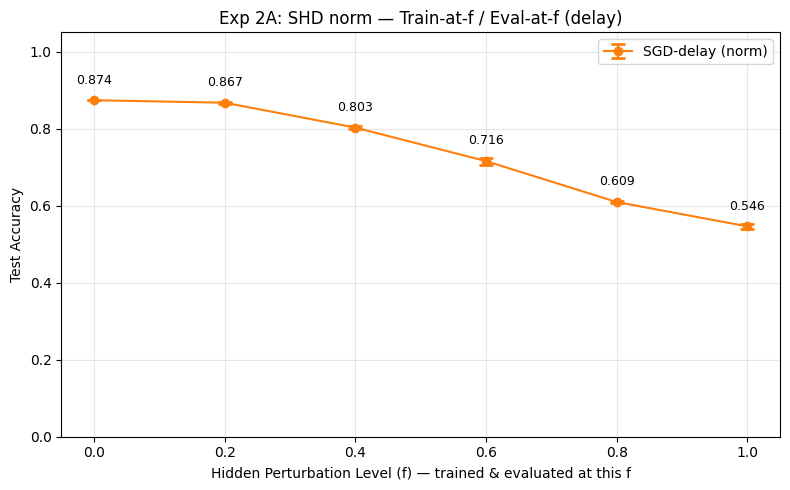

Figure saved to log/shd_norm_delay_hidden_perturbation.png


In [29]:
plot_hidden_perturbation_curve(sweep_results)

In [30]:
print(
    f"=== Learned Parameter Analysis "
    f"(SHD {DATASET_KEY}, {DELAY_TAG}) ===\n"
)

# Per-f delay summary
if USE_DELAY:
    print(f"{'f':>6}  {'d1 mean':>9}  {'d1 std':>9}  {'d2 mean':>9}  {'d2 std':>9}")
    for f_val, mdl in all_models.items():
        d = mdl.get_delays()
        d1 = d.get("delay1")
        d2 = d.get("delay2")
        d1m = float(np.mean(d1)) if d1 is not None and len(d1) > 0 else float("nan")
        d1s = float(np.std(d1)) if d1 is not None and len(d1) > 0 else float("nan")
        d2m = float(np.mean(d2)) if d2 is not None and len(d2) > 0 else float("nan")
        d2s = float(np.std(d2)) if d2 is not None and len(d2) > 0 else float("nan")
        print(f"{f_val:>6.1f}  {d1m:>9.3f}  {d1s:>9.3f}  {d2m:>9.3f}  {d2s:>9.3f}")
else:
    print("No delays (SGD mode)")

# Weight statistics for the f=0 baseline model
baseline = all_models[0.0]
print(f"\nWeight statistics (f=0 baseline):")
for name, param in baseline.named_parameters():
    if "weight" in name:
        w = param.data
        print(
            f"  {name}: mean={w.mean().item():.4f}, "
            f"std={w.std().item():.4f}, "
            f"shape={list(w.shape)}"
        )

=== Learned Parameter Analysis (SHD norm, delay) ===

     f    d1 mean     d1 std    d2 mean     d2 std
   0.0     49.940     27.229     39.849     32.294
   0.2     49.560     26.437     40.376     30.799
   0.4     53.283     24.803     33.174     32.168
   0.6     48.946     28.609     29.402     32.246
   0.8     41.850     31.291     28.843     31.612
   1.0     34.623     32.475     24.315     31.728

Weight statistics (f=0 baseline):
  fc1.weight_g: mean=48.4226, std=37.2010, shape=[128, 1, 1, 1, 1]
  fc1.weight_v: mean=0.7628, std=10.7967, shape=[128, 700, 1, 1, 1]
  fc2.weight_g: mean=77.8963, std=78.2740, shape=[128, 1, 1, 1, 1]
  fc2.weight_v: mean=-0.3251, std=6.9630, shape=[128, 128, 1, 1, 1]
  fc3.weight_g: mean=314.8609, std=43.4008, shape=[20, 1, 1, 1, 1]
  fc3.weight_v: mean=-1.4476, std=8.1595, shape=[20, 128, 1, 1, 1]
